In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
training = pd.read_csv("training_data.csv", encoding="latin1")
test = pd.read_csv("test_data.csv", encoding="latin1")
best = pd.read_csv("melhores_previsoes.csv", encoding="latin1")

In [3]:
training.shape, test.shape, best.shape

((6812, 14), (1500, 13), (1500, 2))

In [4]:
best['Speed_Diff'].fillna("None", inplace=True)

C:\Users\claud\AppData\Local\Temp\ipykernel_14424\3081697609.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  best['Speed_Diff'].fillna("None", inplace=True)


In [5]:
# alinhar
df = test.copy()
df['pred_class'] = best['Speed_Diff'].values
print(df.info())
print(df['pred_class'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city_name                1500 non-null   object 
 1   record_date              1500 non-null   object 
 2   AVERAGE_FREE_FLOW_SPEED  1500 non-null   float64
 3   AVERAGE_TIME_DIFF        1500 non-null   float64
 4   AVERAGE_FREE_FLOW_TIME   1500 non-null   float64
 5   LUMINOSITY               1500 non-null   object 
 6   AVERAGE_TEMPERATURE      1500 non-null   float64
 7   AVERAGE_ATMOSP_PRESSURE  1500 non-null   float64
 8   AVERAGE_HUMIDITY         1500 non-null   float64
 9   AVERAGE_WIND_SPEED       1500 non-null   float64
 10  AVERAGE_CLOUDINESS       901 non-null    object 
 11  AVERAGE_PRECIPITATION    1500 non-null   float64
 12  AVERAGE_RAIN             140 non-null    object 
 13  pred_class               1500 non-null   object 
dtypes: float64(8), object(6)

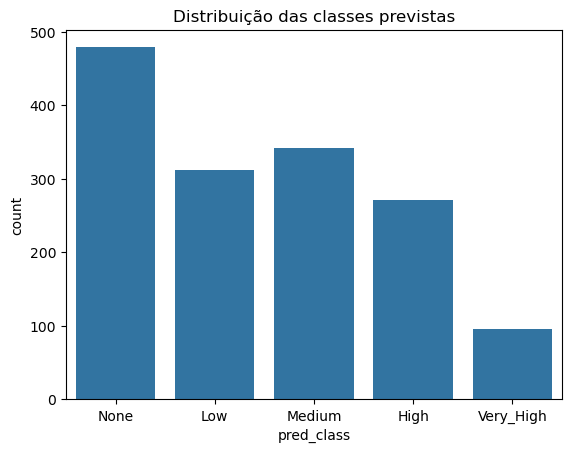

In [6]:
import seaborn as sns

sns.countplot(x='pred_class', data=df, order=["None","Low","Medium","High","Very_High"])
plt.title("Distribuição das classes previstas")
plt.show()

In [7]:
# Converter colunas numéricas
num_cols = [
    'AVERAGE_SPEED_DIFF', 'AVERAGE_FREE_FLOW_SPEED', 'AVERAGE_TIME_DIFF',
    'AVERAGE_FREE_FLOW_TIME', 'AVERAGE_TEMPERATURE', 'AVERAGE_ATMOSP_PRESSURE',
    'AVERAGE_HUMIDITY', 'AVERAGE_WIND_SPEED', 'AVERAGE_PRECIPITATION'
]

for col in num_cols:
    if col in df.columns:  # só converte se a coluna existir
        df[col] = pd.to_numeric(df[col], errors='coerce')


# Média por classe
mean_by_class = df.groupby('pred_class').mean(numeric_only=True)
print(mean_by_class)


            AVERAGE_FREE_FLOW_SPEED  AVERAGE_TIME_DIFF  \
pred_class                                               
High                      39.585978          67.023616   
Low                       40.716026           9.169872   
Medium                    38.742982          27.088304   
None                      42.296451           1.448434   
Very_High                 44.836458          95.243750   

            AVERAGE_FREE_FLOW_TIME  AVERAGE_TEMPERATURE  \
pred_class                                                
High                     82.355720            18.516605   
Low                      80.058013            16.548077   
Medium                   83.469883            18.198830   
None                     80.623382            13.390397   
Very_High                76.351042            13.927083   

            AVERAGE_ATMOSP_PRESSURE  AVERAGE_HUMIDITY  AVERAGE_WIND_SPEED  \
pred_class                                                                  
High                    1

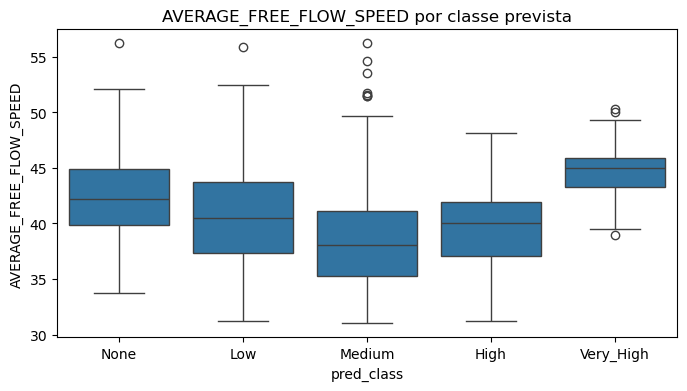

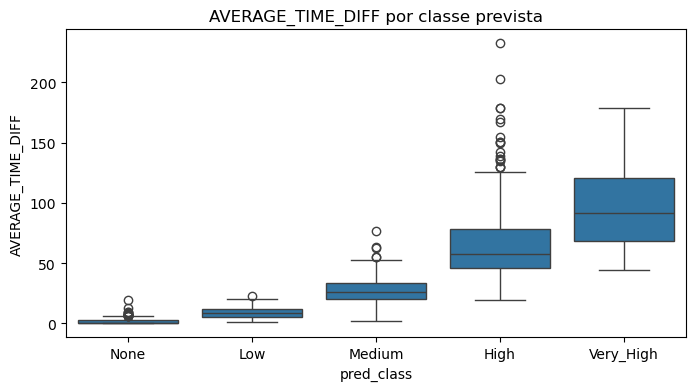

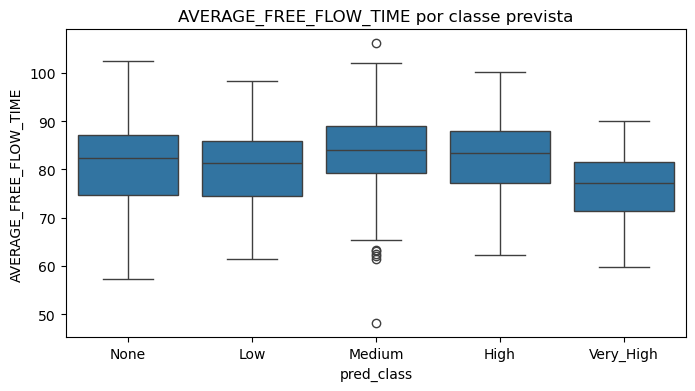

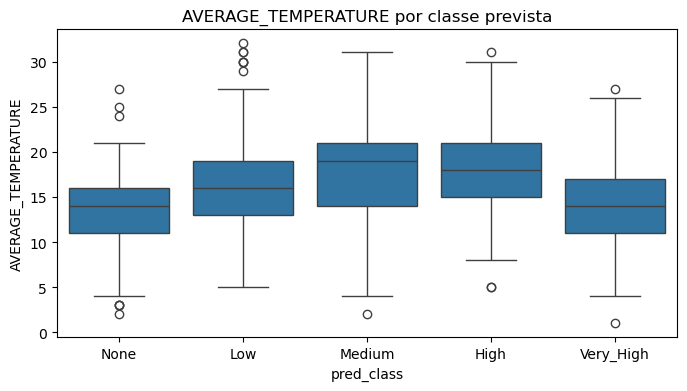

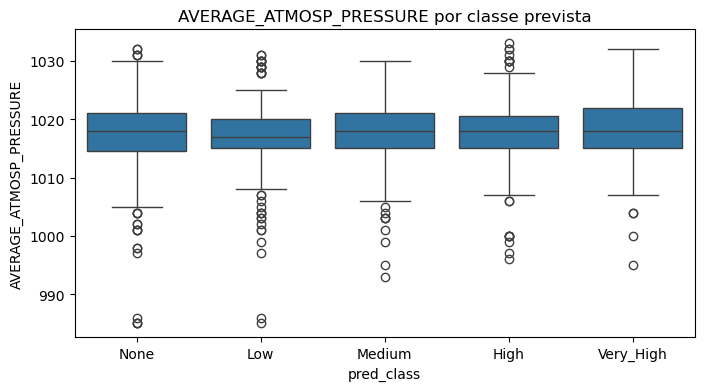

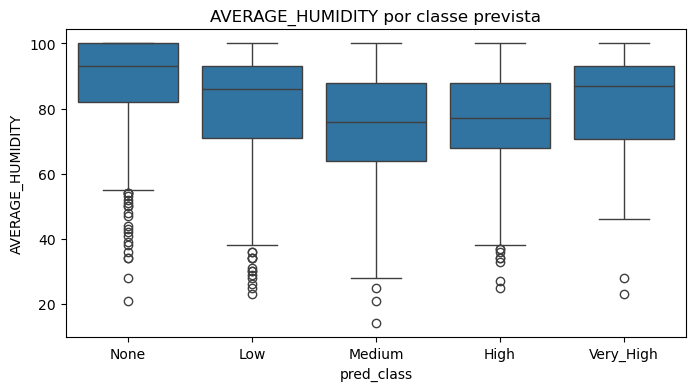

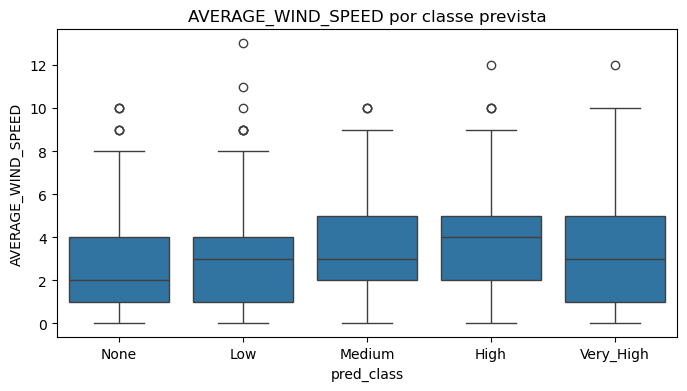

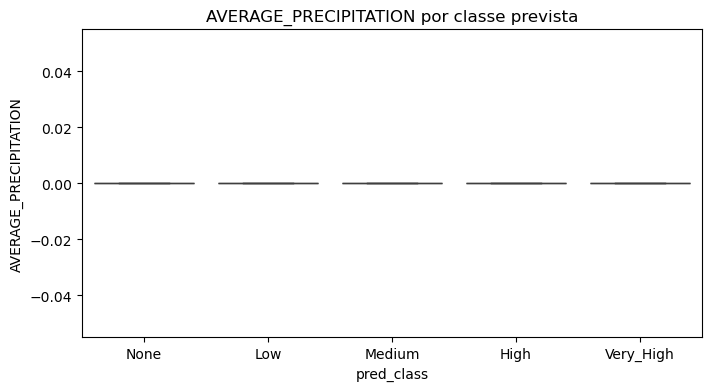

In [8]:
for col in num_cols:
    if col in df.columns:  # só plota se a coluna existir
        plt.figure(figsize=(8,4))
        sns.boxplot(
            x='pred_class', y=col, data=df,
            order=["None","Low","Medium","High","Very_High"]
        )
        plt.title(f"{col} por classe prevista")
        plt.show()


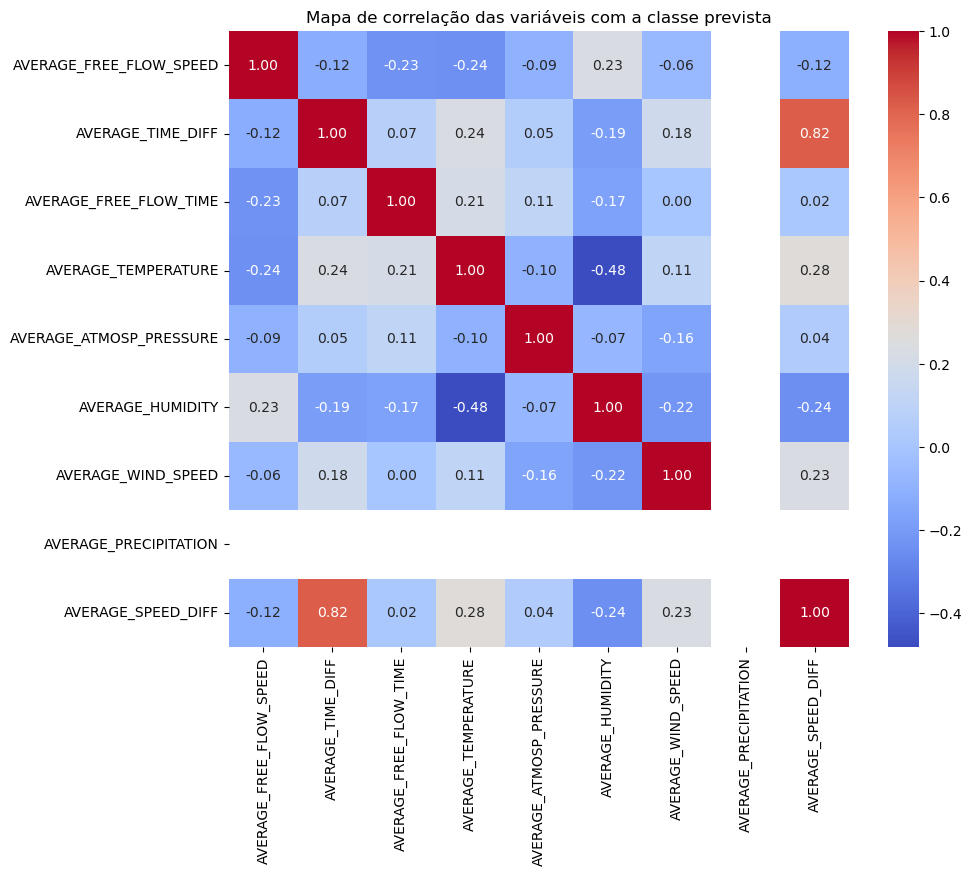

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Transformar labels em número
label_mapper = {"None":0, "Low":1, "Medium":2, "High":3, "Very_High":4}
df['AVERAGE_SPEED_DIFF'] = df['pred_class'].map(label_mapper)

# Selecionar apenas colunas numéricas
num_cols = [
    'AVERAGE_FREE_FLOW_SPEED', 'AVERAGE_TIME_DIFF',
    'AVERAGE_FREE_FLOW_TIME', 'AVERAGE_TEMPERATURE', 'AVERAGE_ATMOSP_PRESSURE',
    'AVERAGE_HUMIDITY', 'AVERAGE_WIND_SPEED', 'AVERAGE_PRECIPITATION'
]

# Garantir que existem no df e são numéricas
num_cols = [col for col in num_cols if col in df.columns]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Criar DataFrame para correlação
corr_df = df[num_cols + ['AVERAGE_SPEED_DIFF']]

# Calcular correlação
corr = corr_df.corr()

# Plotar heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de correlação das variáveis com a classe prevista")
plt.show()
